### QFlow Lite — Graph Neural Networks for Quantum Dot Placement Prediction

**Goal:** Represent quantum dot devices as graphs and use GNNs to predict:
1. **Node-level task** — the state of each quantum dot (Barrier / Single / Double / Short Circuit)  
2. **Graph-level task** — the overall device configuration class




## 0 · Install / verify dependencies

In [1]:
# Uncomment if needed:
# !pip install torch torchvision
# !pip install torch-geometric
import torch, torch_geometric
print(f"PyTorch         : {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}")


C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


PyTorch         : 2.1.2+cpu
PyTorch Geometric: 2.7.0


## 1 · Imports & configuration

In [2]:
import os, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# PyTorch Geometric
from torch_geometric.data import Data, DataLoader as GeoDataLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv,
    global_mean_pool, global_max_pool, global_add_pool,
    BatchNorm
)
from torch_geometric.utils import to_networkx
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## 2 · Configuration

In [3]:
DATA_DIR  = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR   = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/gnn_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "Barrier", 1: "Single Dot", 2: "Double Dot", 3: "Short Circuit"}
N_CLASSES   = 4

# ── Graph construction ────────────────────────────────────────────────────────
GRID_N      = 10      # divide 100×100 map into GRID_N×GRID_N blocks
                      # → each block becomes one graph node
                      # → 10×10 = 100 nodes per graph
CONNECTIVITY = "8"    # "4" = N/S/E/W  |  "8" = + diagonals

# ── GNN training ─────────────────────────────────────────────────────────────
HIDDEN_DIM  = 128
N_LAYERS    = 3
DROPOUT     = 0.3
BATCH_SIZE  = 32
N_EPOCHS    = 150
LR          = 3e-3
WEIGHT_DECAY= 1e-4
TEST_SIZE   = 0.20
RANDOM_STATE= 42

print(f"Graph: {GRID_N}×{GRID_N} = {GRID_N**2} nodes per sample")
print(f"Node connectivity: {CONNECTIVITY}-connected grid")
print(f"Node feature dim : 7  (current, sensor, charge occupancy,")
print(f"                       row, col, norm_row, norm_col)")


Graph: 10×10 = 100 nodes per sample
Node connectivity: 8-connected grid
Node feature dim : 7  (current, sensor, charge occupancy,
                       row, col, norm_row, norm_col)


## 3 · Load raw QFlow data

In [4]:
def charge_to_float(c):
    try:
        return float(len(c)) if hasattr(c, '__len__') else float(c)
    except Exception:
        return 0.0


def load_raw_samples(data_dir):
    """
    Returns list of dicts, each with:
      'current'  : (100,100) float32
      'sensor'   : (100,100) float32
      'charge'   : (100,100) float32
      'pixel_state': (100,100) int    ← per-pixel device state
      'label'    : int                ← majority device state
    """
    files = sorted([f for f in os.listdir(data_dir)
                    if f.endswith('.npy') and not f.startswith('.')])
    samples, skipped = [], 0

    for fname in files:
        try:
            raw    = np.load(data_dir / fname, allow_pickle=True).item()
            output = raw['output']
            if len(output) != 10000:
                skipped += 1; continue

            current_map   = np.array([p['current']   for p in output],
                                     dtype=np.float32).reshape(100, 100)
            sensor_map    = np.array(
                [p['sensor'][0] if hasattr(p['sensor'], '__len__')
                 else float(p['sensor']) for p in output],
                dtype=np.float32).reshape(100, 100)
            charge_map    = np.array([charge_to_float(p['charge']) for p in output],
                                     dtype=np.float32).reshape(100, 100)
            pixel_state   = np.array([p['state'] for p in output],
                                     dtype=np.int64).reshape(100, 100)
            states        = [p['state'] for p in output]
            label         = int(max(set(states), key=states.count))

            samples.append({
                "current"     : current_map,
                "sensor"      : sensor_map,
                "charge"      : charge_map,
                "pixel_state" : pixel_state,
                "label"       : label,
            })
        except Exception as e:
            skipped += 1

    if skipped:
        print(f"Skipped {skipped} files.")
    return samples


print("Loading raw samples …")
samples = load_raw_samples(DATA_DIR)
print(f"Loaded {len(samples)} samples")

label_counts = Counter(s['label'] for s in samples)
print("\nClass distribution:")
for k, name in LABEL_NAMES.items():
    n   = label_counts.get(k, 0)
    bar = "█" * int(n / len(samples) * 40)
    print(f"  {name:<14} ({k})  {n:>4}  {bar}")


Loading raw samples …
Loaded 1001 samples

Class distribution:
  Barrier        (0)    18  
  Single Dot     (1)   756  ██████████████████████████████
  Double Dot     (2)   227  █████████
  Short Circuit  (3)     0  


## 4 · Build graph representation

Each 100×100 map is divided into **GRID_N × GRID_N blocks**.  
Each block → one graph **node** with 7 features:

| Feature | Description |
|---------|-------------|
| `current_mean` | Mean current in block (log-scaled) |
| `sensor_mean`  | Mean sensor / Coulomb value |
| `charge_mean`  | Mean charge occupancy |
| `current_std`  | Std of current (texture) |
| `row`          | Block row index (integer) |
| `col`          | Block column index (integer) |
| `norm_pos`     | Normalised diagonal position (row+col)/(2*(N-1)) |

**Edges** connect each node to its 4 or 8 spatial neighbours.  
**Node label** = majority pixel state inside the block.  
**Graph label** = overall device state (used for graph classification).


In [5]:
def log_norm(arr):
    """Signed log normalisation to handle large dynamic range."""
    return np.sign(arr) * np.log1p(np.abs(arr))


def build_graph(sample, grid_n=GRID_N, connectivity=CONNECTIVITY):
    """
    Convert one QFlow sample dict into a PyG Data object.

    Returns Data with:
      x          : (grid_n^2, 7) node features
      edge_index : (2, E) adjacency
      y_node     : (grid_n^2,)   per-node state label
      y_graph    : scalar        graph-level label
    """
    H, W   = 100, 100
    bh, bw = H // grid_n, W // grid_n   # block height / width

    node_feats  = []
    node_labels = []

    cur_log = log_norm(sample['current'])
    sen_raw = sample['sensor']
    chg_raw = sample['charge']
    pst     = sample['pixel_state']

    for r in range(grid_n):
        for c in range(grid_n):
            # Pixel slice for this block
            rs = r * bh; re = rs + bh
            cs = c * bw; ce = cs + bw

            cur_block = cur_log[rs:re, cs:ce]
            sen_block = sen_raw[rs:re, cs:ce]
            chg_block = chg_raw[rs:re, cs:ce]
            pst_block = pst[rs:re, cs:ce]

            feats = [
                float(cur_block.mean()),
                float(sen_block.mean()),
                float(chg_block.mean()),
                float(cur_block.std()),
                float(r) / max(grid_n - 1, 1),          # normalised row
                float(c) / max(grid_n - 1, 1),          # normalised col
                float(r + c) / max(2 * (grid_n - 1), 1) # diagonal pos
            ]
            node_feats.append(feats)

            # Node label = majority pixel state in block
            states_in_block = pst_block.flatten().tolist()
            node_labels.append(int(max(set(states_in_block),
                                       key=states_in_block.count)))

    x       = torch.tensor(node_feats, dtype=torch.float)
    y_node  = torch.tensor(node_labels, dtype=torch.long)
    y_graph = torch.tensor(sample['label'], dtype=torch.long)

    # Build edge index — grid adjacency
    edges_src, edges_dst = [], []

    def node_id(r, c): return r * grid_n + c

    for r in range(grid_n):
        for c in range(grid_n):
            nid = node_id(r, c)
            # 4-connected neighbours
            neighbours = []
            if r > 0:           neighbours.append(node_id(r-1, c))
            if r < grid_n - 1:  neighbours.append(node_id(r+1, c))
            if c > 0:           neighbours.append(node_id(r, c-1))
            if c < grid_n - 1:  neighbours.append(node_id(r, c+1))
            # extra 4 diagonal neighbours for 8-connectivity
            if connectivity == "8":
                if r > 0 and c > 0:              neighbours.append(node_id(r-1, c-1))
                if r > 0 and c < grid_n - 1:     neighbours.append(node_id(r-1, c+1))
                if r < grid_n-1 and c > 0:       neighbours.append(node_id(r+1, c-1))
                if r < grid_n-1 and c < grid_n-1:neighbours.append(node_id(r+1, c+1))

            for nb in neighbours:
                edges_src.append(nid); edges_dst.append(nb)

    edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

    return Data(x=x, edge_index=edge_index,
                y=y_graph, y_node=y_node)


# Build all graphs
print("Building graphs …")
t0 = time.time()
graph_list = [build_graph(s) for s in samples]
print(f"Built {len(graph_list)} graphs in {time.time()-t0:.1f}s")

g0 = graph_list[0]
print(f"\nExample graph:")
print(f"  Nodes       : {g0.num_nodes}   (features: {g0.x.shape[1]})")
print(f"  Edges       : {g0.num_edges}")
print(f"  Graph label : {g0.y.item()} = {LABEL_NAMES[g0.y.item()]}")
print(f"  Node labels : {g0.y_node.tolist()[:10]} …")
print(f"  x range     : [{g0.x.min():.3f}, {g0.x.max():.3f}]")


Building graphs …
Built 1001 graphs in 20.7s

Example graph:
  Nodes       : 100   (features: 7)
  Edges       : 684
  Graph label : 1 = Single Dot
  Node labels : [0, 0, 1, 1, 1, 1, 1, 1, 1, 1] …
  x range     : [0.000, 2.000]


## 5 · Visualise graph structure on top of stability map

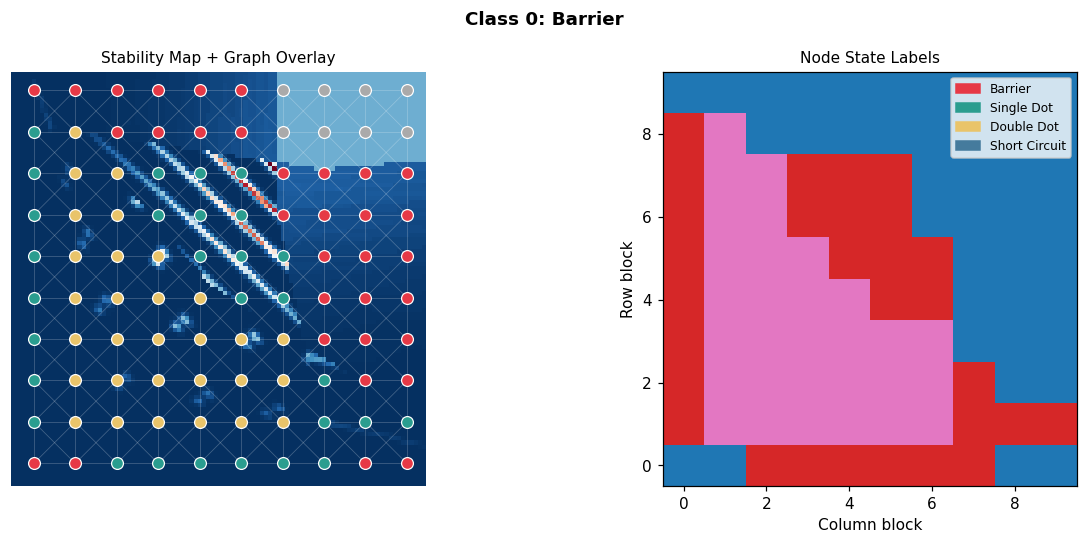

Saved → graph_visualisation.png


In [7]:
def visualise_graph(sample, graph, title=""):
    colors_node = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]
    FALLBACK_CLR = "#aaaaaa"
    label_colors = {k: colors_node[k] for k in range(N_CLASSES)}

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title or f"Device: {LABEL_NAMES[sample['label']]}",
                 fontsize=12, fontweight="bold")

    # Left: raw current map
    ax = axes[0]
    cur_disp = np.log1p(np.abs(sample['current']))
    ax.imshow(cur_disp, cmap="RdBu_r", origin="lower")

    # Overlay graph edges and nodes
    G = to_networkx(graph, to_undirected=True)
    grid_n = GRID_N
    node_colors = [label_colors.get(graph.y_node[n].item(), FALLBACK_CLR) for n in range(graph.num_nodes)]

    # Draw edges on the image
    for u, v in G.edges():
        r1, c1 = divmod(u, grid_n)
        r2, c2 = divmod(v, grid_n)
        # Map block coords to pixel coords (centre of block)
        bh, bw = 100 // grid_n, 100 // grid_n
        x1 = c1 * bw + bw // 2; y1 = r1 * bh + bh // 2
        x2 = c2 * bw + bw // 2; y2 = r2 * bh + bh // 2
        ax.plot([x1, x2], [y1, y2], 'w-', alpha=0.25, lw=0.5)

    # Draw nodes
    for n in range(graph.num_nodes):
        r, c = divmod(n, grid_n)
        bh, bw = 100 // grid_n, 100 // grid_n
        px = c * bw + bw // 2; py = r * bh + bh // 2
        ax.scatter(px, py, c=node_colors[n], s=60,
                   edgecolors='white', linewidths=0.8, zorder=5)

    ax.set_title("Stability Map + Graph Overlay", fontsize=10)
    ax.axis("off")

    # Right: node state heatmap
    ax2 = axes[1]
    state_grid = graph.y_node.numpy().reshape(grid_n, grid_n)
    im = ax2.imshow(state_grid, cmap="tab10", vmin=0, vmax=3, origin="lower")
    ax2.set_title("Node State Labels", fontsize=10)
    ax2.set_xlabel("Column block"); ax2.set_ylabel("Row block")
    patches = [mpatches.Patch(color=colors_node[k], label=LABEL_NAMES[k])
               for k in range(N_CLASSES)]
    ax2.legend(handles=patches, fontsize=8, loc="upper right")

    plt.tight_layout()
    #fig.savefig(OUT_DIR / "graph_visualisation.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("Saved → graph_visualisation.png")


# Pick one sample of each class
for cls in range(N_CLASSES):
    idx = next(i for i, s in enumerate(samples) if s['label'] == cls)
    visualise_graph(samples[idx], graph_list[idx],
                    title=f"Class {cls}: {LABEL_NAMES[cls]}")
    break   # show just one; remove break to show all 4


## 6 · Train / test split

In [8]:
labels_all = [g.y.item() for g in graph_list]

train_graphs, test_graphs, y_tr, y_te = train_test_split(
    graph_list, labels_all,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels_all
)

train_loader = GeoDataLoader(train_graphs, batch_size=BATCH_SIZE,
                             shuffle=True)
test_loader  = GeoDataLoader(test_graphs,  batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Train: {len(train_graphs)} graphs  |  Test: {len(test_graphs)} graphs")
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

ALL_LABELS  = sorted(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[k] for k in ALL_LABELS]


Train: 800 graphs  |  Test: 201 graphs
Train batches: 25  |  Test batches: 7


## 7 · GNN model definitions

Three architectures are compared:

| Model | Conv type | Key property |
|-------|-----------|--------------|
| **GCN** | `GCNConv` | Spectral graph convolution — simple, fast |
| **GAT** | `GATConv` | Attention weights per edge — learns which neighbours matter |
| **GraphSAGE** | `SAGEConv` | Inductive — aggregates sampled neighbours |

All share the same head: graph-level readout (mean+max pooling) → MLP → 4-class softmax.


In [9]:
class GNNClassifier(nn.Module):
    """
    Unified GNN for graph-level classification.
    conv_type: 'GCN' | 'GAT' | 'SAGE'
    """
    def __init__(self, in_dim, hidden_dim, n_classes,
                 n_layers=N_LAYERS, dropout=DROPOUT,
                 conv_type="GCN", heads=4):
        super().__init__()
        self.conv_type = conv_type
        self.dropout   = dropout
        self.convs     = nn.ModuleList()
        self.bns       = nn.ModuleList()

        for i in range(n_layers):
            in_ch  = in_dim if i == 0 else hidden_dim
            out_ch = hidden_dim

            if conv_type == "GCN":
                self.convs.append(GCNConv(in_ch, out_ch))
            elif conv_type == "GAT":
                # Multi-head attention; concat → divide to keep dim
                h = heads if i < n_layers - 1 else 1
                self.convs.append(GATConv(in_ch, out_ch // h,
                                          heads=h, dropout=dropout))
            elif conv_type == "SAGE":
                self.convs.append(SAGEConv(in_ch, out_ch))

            self.bns.append(BatchNorm(out_ch))

        # Graph readout: mean + max pooling → double the dim
        readout_dim = hidden_dim * 2

        self.head = nn.Sequential(
            nn.Linear(readout_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Dual readout
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x_pool = torch.cat([x_mean, x_max], dim=1)

        return self.head(x_pool)


IN_DIM = graph_list[0].x.shape[1]   # 7 node features

models = {
    "GCN"      : GNNClassifier(IN_DIM, HIDDEN_DIM, N_CLASSES, conv_type="GCN"),
    "GAT"      : GNNClassifier(IN_DIM, HIDDEN_DIM, N_CLASSES, conv_type="GAT"),
    "GraphSAGE": GNNClassifier(IN_DIM, HIDDEN_DIM, N_CLASSES, conv_type="SAGE"),
}

for name, model in models.items():
    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:<12}: {n_p:>8,} parameters")


  GCN         :   76,228 parameters
  GAT         :   76,996 parameters
  GraphSAGE   :  109,892 parameters


## 8 · Training & evaluation functions

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        pred        = out.argmax(dim=1)
        correct    += (pred == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.batch)
        loss  = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        pred        = out.argmax(dim=1)
        correct    += (pred == batch.y).sum().item()
        total      += batch.num_graphs
        all_preds.extend(pred.cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(name, model, n_epochs=N_EPOCHS):
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=LR,
                     weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_loss": [],
               "train_acc":  [], "test_acc":  []}
    best_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc, preds, labels = evaluate(model, test_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if te_acc > best_acc:
            best_acc   = te_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_preds = preds
            best_labels= labels

        if epoch % 25 == 0 or epoch == 1:
            print(f"  [{name}] Epoch {epoch:3d}/{n_epochs} | "
                  f"Train acc: {tr_acc*100:.1f}%  "
                  f"Test acc: {te_acc*100:.1f}%  "
                  f"loss: {te_loss:.4f}")

    elapsed = time.time() - t0
    model.load_state_dict(best_state)
    print(f"  [{name}] Best test accuracy: {best_acc*100:.2f}%  "
          f"| Time: {elapsed:.1f}s")

    return model, history, best_acc, best_preds, best_labels

print("Training and evaluation functions defined.")


Training and evaluation functions defined.


## 9 · Train all three GNN models

In [11]:
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")
    trained_model, history, best_acc, preds, labels = train_model(
        model_name, model, n_epochs=N_EPOCHS
    )
    results[model_name] = {
        "model"   : trained_model,
        "history" : history,
        "best_acc": best_acc,
        "preds"   : preds,
        "labels"  : labels,
    }

print("\n✓ All GNN models trained.")



  Training GCN
  [GCN] Epoch   1/150 | Train acc: 68.0%  Test acc: 75.6%  loss: 0.9245
  [GCN] Epoch  25/150 | Train acc: 89.5%  Test acc: 92.5%  loss: 0.2330
  [GCN] Epoch  50/150 | Train acc: 89.8%  Test acc: 84.6%  loss: 0.2824
  [GCN] Epoch  75/150 | Train acc: 94.1%  Test acc: 93.5%  loss: 0.1688
  [GCN] Epoch 100/150 | Train acc: 94.9%  Test acc: 88.1%  loss: 0.2251
  [GCN] Epoch 125/150 | Train acc: 93.9%  Test acc: 96.0%  loss: 0.1312
  [GCN] Epoch 150/150 | Train acc: 93.4%  Test acc: 97.0%  loss: 0.1277
  [GCN] Best test accuracy: 97.51%  | Time: 368.0s

  Training GAT
  [GAT] Epoch   1/150 | Train acc: 70.8%  Test acc: 75.6%  loss: 0.9426
  [GAT] Epoch  25/150 | Train acc: 85.1%  Test acc: 77.6%  loss: 0.4726
  [GAT] Epoch  50/150 | Train acc: 86.9%  Test acc: 78.6%  loss: 0.5511
  [GAT] Epoch  75/150 | Train acc: 89.2%  Test acc: 79.6%  loss: 0.5130
  [GAT] Epoch 100/150 | Train acc: 89.8%  Test acc: 79.1%  loss: 0.7225
  [GAT] Epoch 125/150 | Train acc: 90.8%  Test acc: 7

## 10 · Learning curves

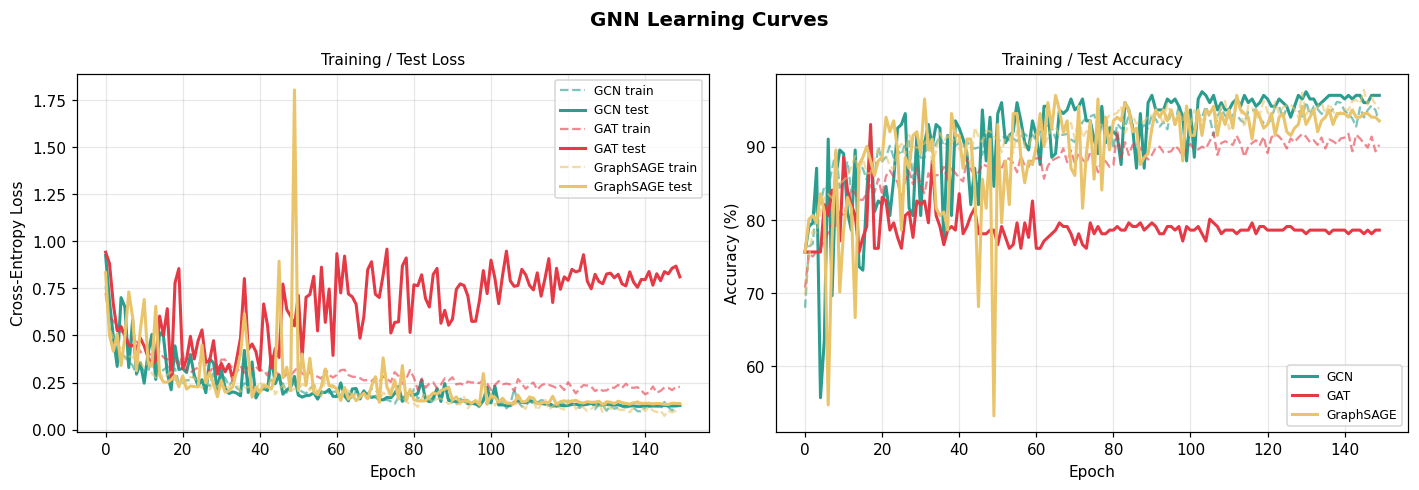

Saved → gnn_learning_curves.png


In [12]:
colors = {"GCN": "#2a9d8f", "GAT": "#e63946", "GraphSAGE": "#e9c46a"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("GNN Learning Curves", fontsize=13, fontweight="bold")

for name, res in results.items():
    h = res["history"]
    axes[0].plot(h["train_loss"], lw=1.5, color=colors[name],
                 linestyle="--", alpha=0.6, label=f"{name} train")
    axes[0].plot(h["test_loss"],  lw=2.0, color=colors[name],
                 label=f"{name} test")
    axes[1].plot(np.array(h["train_acc"]) * 100, lw=1.5, color=colors[name],
                 linestyle="--", alpha=0.6)
    axes[1].plot(np.array(h["test_acc"]) * 100,  lw=2.0, color=colors[name],
                 label=name)

for ax, ylabel, title in zip(
    axes,
    ["Cross-Entropy Loss", "Accuracy (%)"],
    ["Training / Test Loss", "Training / Test Accuracy"]
):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
#fig.savefig(OUT_DIR / "gnn_learning_curves.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved → gnn_learning_curves.png")


## 11 · Confusion matrices & classification reports

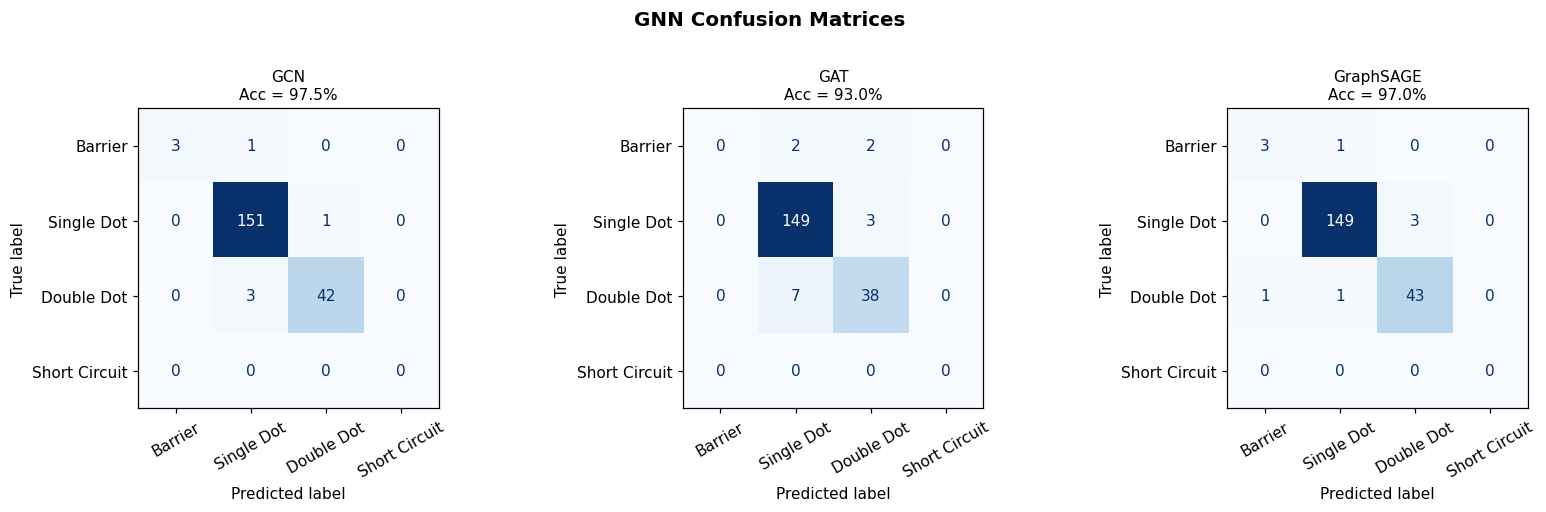

Saved → gnn_confusion_matrices.png

───────────────────────────────────────────────────────
  GCN  (best test acc: 97.51%)
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

      Barrier       1.00      0.75      0.86         4
   Single Dot       0.97      0.99      0.98       152
   Double Dot       0.98      0.93      0.95        45
Short Circuit       0.00      0.00      0.00         0

     accuracy                           0.98       201
    macro avg       0.74      0.67      0.70       201
 weighted avg       0.98      0.98      0.97       201


───────────────────────────────────────────────────────
  GAT  (best test acc: 93.03%)
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

      Barrier       0.00      0.00      0.00         4
   Single Dot       0.94      0.98      0.96       152
   Double Dot       0.88      0.84      0.86        45
Short Circuit

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(res["labels"], res["preds"],
                            labels=ALL_LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
    ax.set_title(f"{name}\nAcc = {res['best_acc']*100:.1f}%", fontsize=10)

plt.suptitle("GNN Confusion Matrices", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
#fig.savefig(OUT_DIR / "gnn_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved → gnn_confusion_matrices.png")

for name, res in results.items():
    print(f"\n{'─'*55}")
    print(f"  {name}  (best test acc: {res['best_acc']*100:.2f}%)")
    print('─'*55)
    print(classification_report(
        res["labels"], res["preds"],
        labels=ALL_LABELS, target_names=CLASS_NAMES,
        zero_division=0
    ))


## 12 · Model accuracy comparison

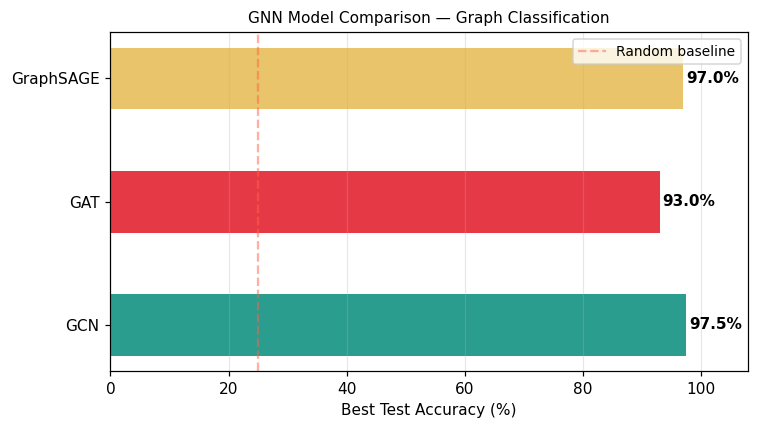

Saved → gnn_accuracy_comparison.png


In [14]:
names = list(results.keys())
accs  = [results[n]["best_acc"] * 100 for n in names]
clrs  = [colors[n] for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(names, accs, color=clrs, height=0.5)
ax.set_xlim(0, 108)
ax.set_xlabel("Best Test Accuracy (%)")
ax.set_title("GNN Model Comparison — Graph Classification")
ax.axvline(25, color="tomato", ls="--", alpha=0.5, label="Random baseline")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(acc + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{acc:.1f}%", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
#fig.savefig(OUT_DIR / "gnn_accuracy_comparison.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved → gnn_accuracy_comparison.png")


## 13 · Node-level placement prediction

Extend the best GNN to predict the **state of each individual quantum dot node**  
— this is the core placement prediction task: given the graph topology, which  
nodes are dots, which are barriers, which are short circuits?


In [16]:
class NodeGNN(nn.Module):
    """
    GNN for node-level state prediction.
    Uses the best-performing conv type from graph classification.
    """
    def __init__(self, in_dim, hidden_dim, n_classes,
                 n_layers=N_LAYERS, dropout=DROPOUT, conv_type="SAGE"):
        super().__init__()
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()
        self.dropout = dropout

        for i in range(n_layers):
            in_ch = in_dim if i == 0 else hidden_dim
            if conv_type == "GCN":
                self.convs.append(GCNConv(in_ch, hidden_dim))
            elif conv_type == "GAT":
                h = 4 if i < n_layers - 1 else 1
                self.convs.append(GATConv(in_ch, hidden_dim // h,
                                          heads=h, dropout=dropout))
            elif conv_type == "SAGE":
                self.convs.append(SAGEConv(in_ch, hidden_dim))
            self.bns.append(BatchNorm(hidden_dim))

        # Node-level classification head
        self.node_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x, edge_index, batch=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.node_head(x)   # (N_total_nodes, n_classes)


node_model = NodeGNN(IN_DIM, HIDDEN_DIM, N_CLASSES, conv_type="SAGE").to(device)
n_params = sum(p.numel() for p in node_model.parameters() if p.requires_grad)
print(f"NodeGNN parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer_node = Adam(node_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_node = CosineAnnealingLR(optimizer_node, T_max=N_EPOCHS, eta_min=1e-5)
criterion_node = nn.CrossEntropyLoss(ignore_index=-1)

node_history   = {"train_loss": [], "test_loss": [],
                  "train_acc":  [], "test_acc":  []}
best_node_acc  = 0.0
best_node_state= None

print(f"Training NodeGNN for {N_EPOCHS} epochs …")
t0 = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    node_model.train()
    tr_loss = tr_correct = tr_total = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer_node.zero_grad()
        out  = node_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion_node(out, batch.y_node)
        loss.backward()
        optimizer_node.step()
        tr_loss    += loss.item() * batch.y_node.size(0)
        tr_correct += (out.argmax(1) == batch.y_node).sum().item()
        tr_total   += batch.y_node.size(0)
    scheduler_node.step()

    # ── Evaluate ───────────────────────────────────────────────────────────
    node_model.eval()
    te_loss = te_correct = te_total = 0
    node_preds_all = []; node_labels_all = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = node_model(batch.x, batch.edge_index, batch.batch)
            loss  = criterion_node(out, batch.y_node)
            te_loss    += loss.item() * batch.y_node.size(0)
            pred        = out.argmax(1)
            te_correct += (pred == batch.y_node).sum().item()
            te_total   += batch.y_node.size(0)
            node_preds_all.extend(pred.cpu().tolist())
            node_labels_all.extend(batch.y_node.cpu().tolist())

    tr_acc = tr_correct / tr_total
    te_acc = te_correct / te_total
    node_history["train_loss"].append(tr_loss / tr_total)
    node_history["test_loss"].append(te_loss / te_total)
    node_history["train_acc"].append(tr_acc)
    node_history["test_acc"].append(te_acc)

    if te_acc > best_node_acc:
        best_node_acc   = te_acc
        best_node_state = {k: v.clone() for k, v in node_model.state_dict().items()}
        best_node_preds = node_preds_all
        best_node_labels= node_labels_all

    if epoch % 25 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Train: {tr_acc*100:.1f}%  Test: {te_acc*100:.1f}%  "
              f"loss: {te_loss/te_total:.4f}")

node_model.load_state_dict(best_node_state)
print(f"\n✓ Best node-level accuracy: {best_node_acc*100:.2f}%  "
      f"| Time: {time.time()-t0:.1f}s")


NodeGNN parameters: 76,996
Training NodeGNN for 150 epochs …
  Epoch   1/150 | Train: 82.9%  Test: 84.3%  loss: 0.3866
  Epoch  25/150 | Train: 95.9%  Test: 96.4%  loss: 0.0341
  Epoch  50/150 | Train: 96.3%  Test: 96.8%  loss: 0.0258
  Epoch  75/150 | Train: 96.4%  Test: 96.7%  loss: 0.0264
  Epoch 100/150 | Train: 96.8%  Test: 96.9%  loss: 0.0202
  Epoch 125/150 | Train: 97.0%  Test: 97.0%  loss: 0.0181
  Epoch 150/150 | Train: 97.0%  Test: 97.0%  loss: 0.0169

✓ Best node-level accuracy: 97.09%  | Time: 304.9s


## 14 · Visualise node-level placement predictions

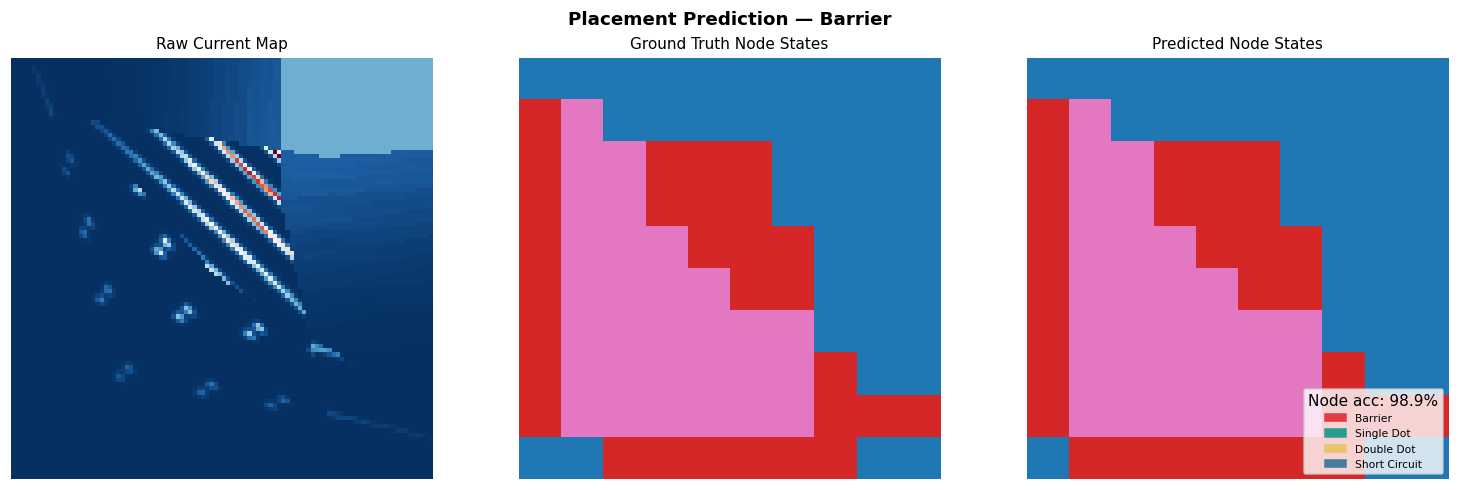

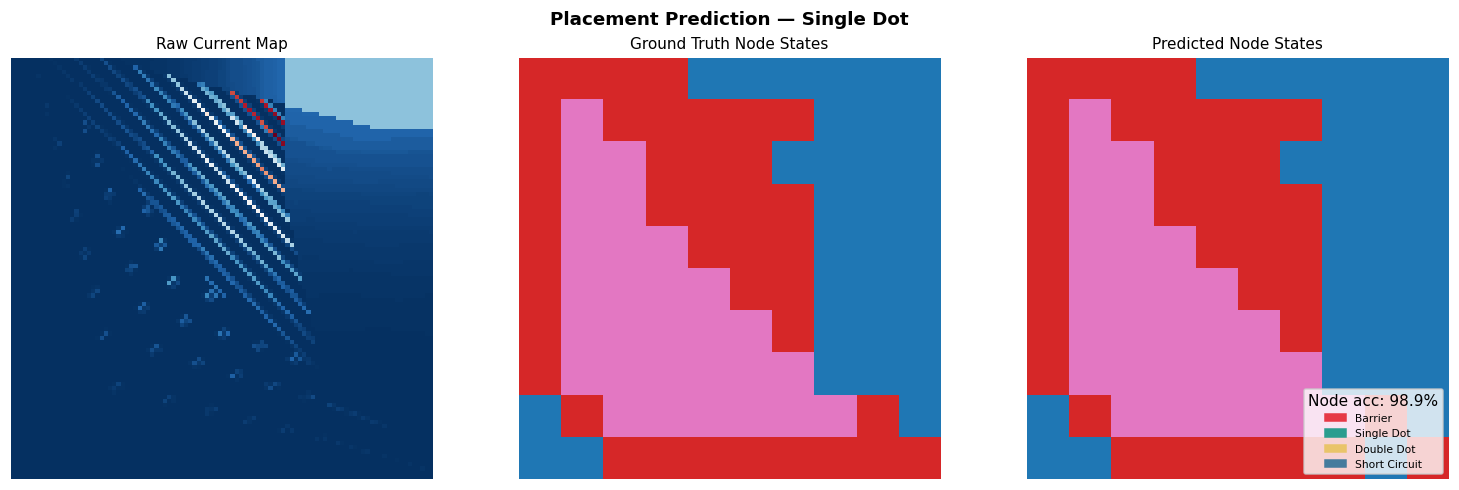

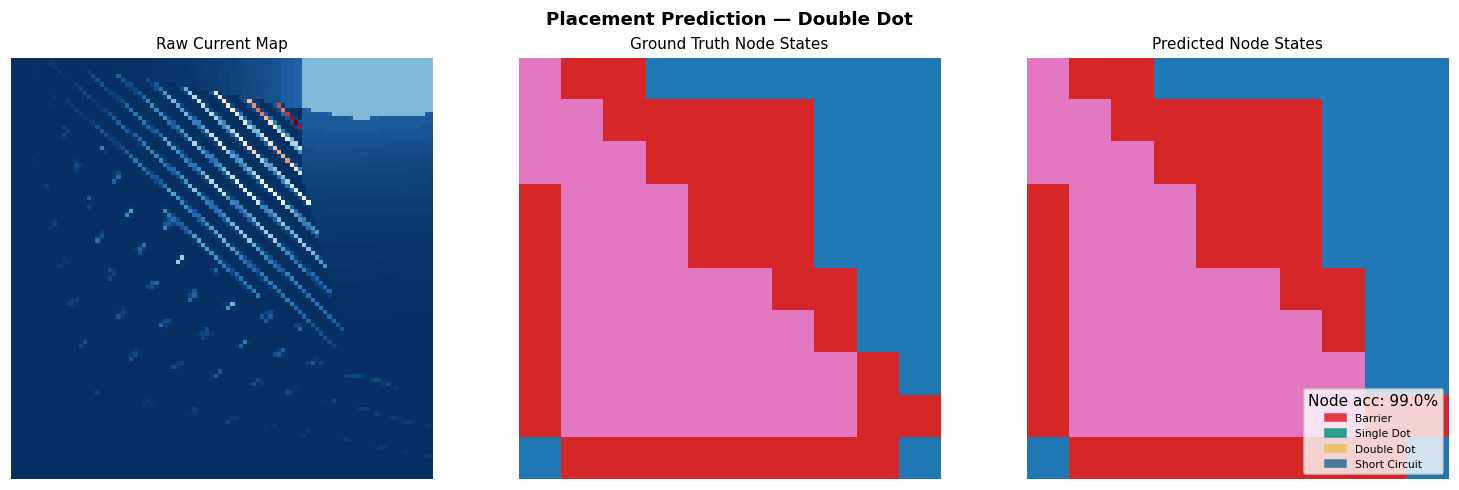

Skipping class 3 (Short Circuit) — no samples found
Done visualizing node predictions


In [27]:
from collections import defaultdict
def visualise_node_predictions(sample, graph, node_model, title=""):
    node_model.eval()
    data = graph.to(device)
    with torch.no_grad():
        logits = node_model(data.x, data.edge_index)
        preds  = logits.argmax(1).cpu().numpy()
    true_labels = graph.y_node.numpy()

    colors_map = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.suptitle(title or f"Node Placement Predictions — {LABEL_NAMES[sample['label']]}",
                 fontsize=12, fontweight="bold")

    # Raw map
    axes[0].imshow(np.log1p(np.abs(sample['current'])),
                   cmap="RdBu_r", origin="lower")
    axes[0].set_title("Raw Current Map"); axes[0].axis("off")

    # Ground truth
    gt_grid = true_labels.reshape(GRID_N, GRID_N)
    im1 = axes[1].imshow(gt_grid, cmap="tab10", vmin=0, vmax=3, origin="lower")
    axes[1].set_title("Ground Truth Node States"); axes[1].axis("off")

    # Predictions
    pr_grid = preds.reshape(GRID_N, GRID_N)
    im2 = axes[2].imshow(pr_grid, cmap="tab10", vmin=0, vmax=3, origin="lower")
    axes[2].set_title("Predicted Node States"); axes[2].axis("off")

    # Accuracy for this graph
    mask = true_labels != -1
    if mask.sum() > 0:
        node_acc = (preds[mask] == true_labels[mask]).mean() * 100
    else:
        node_acc = 0.0
    
    #node_acc = (preds == true_labels).mean() * 100
    patches  = [mpatches.Patch(color=colors_map[k], label=LABEL_NAMES[k])
                for k in range(N_CLASSES)]
    axes[2].legend(handles=patches, fontsize=7, loc="lower right",
                   title=f"Node acc: {node_acc:.1f}%")

    plt.tight_layout()
    #fig.savefig(OUT_DIR / f"node_pred_{LABEL_NAMES[sample['label']].replace(' ','_')}.png",dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)


# Show one example per class
class_to_indices = defaultdict(list)
for i, s in enumerate(samples):
    class_to_indices[s['label']].append(i)

# ── Visualize one example per class ───────────────────────────────────────────
for cls in range(N_CLASSES):
    if cls not in class_to_indices:
        print(f"Skipping class {cls} ({LABEL_NAMES[cls]}) — no samples found")
        continue

    idx = class_to_indices[cls][0]

    visualise_node_predictions(
        samples[idx],
        graph_list[idx],
        node_model,
        title=f"Placement Prediction — {LABEL_NAMES[cls]}"
    )

print("Done visualizing node predictions")


In [33]:
from collections import Counter
print(Counter(s['label'] for s in samples))

Counter({1: 756, 2: 227, 0: 18})


## 15 · Node-level classification report

Node-level Placement Prediction Report
               precision    recall  f1-score   support

      Barrier       0.87      0.99      0.92      3433
   Single Dot       0.99      0.99      0.99      8755
   Double Dot       1.00      1.00      1.00      7456
Short Circuit       0.00      0.00      0.00         0

    micro avg       0.97      0.99      0.98     19644
    macro avg       0.71      0.74      0.73     19644
 weighted avg       0.97      0.99      0.98     19644



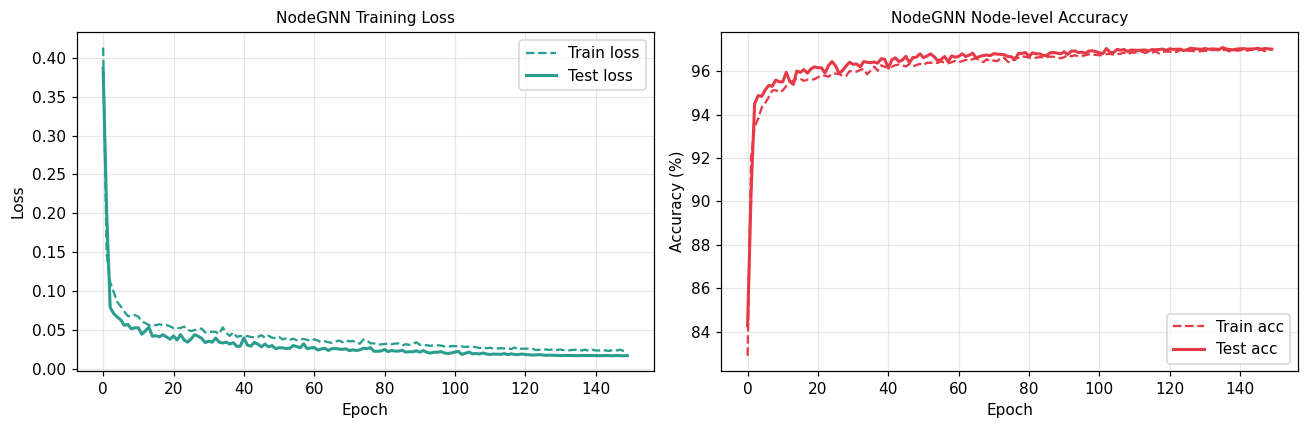

Saved → node_gnn_curves.png


In [28]:
print("Node-level Placement Prediction Report")
print("="*55)
print(classification_report(
    best_node_labels, best_node_preds,
    labels=ALL_LABELS, target_names=CLASS_NAMES,
    zero_division=0
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(node_history["train_loss"], lw=1.5, ls="--",
             color="#2a9d8f", label="Train loss")
axes[0].plot(node_history["test_loss"],  lw=2.0,
             color="#2a9d8f", label="Test loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("NodeGNN Training Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(np.array(node_history["train_acc"]) * 100, lw=1.5, ls="--",
             color="#e63946", label="Train acc")
axes[1].plot(np.array(node_history["test_acc"])  * 100, lw=2.0,
             color="#e63946", label="Test acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("NodeGNN Node-level Accuracy"); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#fig.savefig(OUT_DIR / "node_gnn_curves.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved → node_gnn_curves.png")


## 16 · GAT Attention weight visualisation

For the GAT model, we can inspect which edges the model attends to most —  
revealing which inter-dot couplings are most informative for classification.


Training GAT (with attention) …
Done. Extracting attention weights …


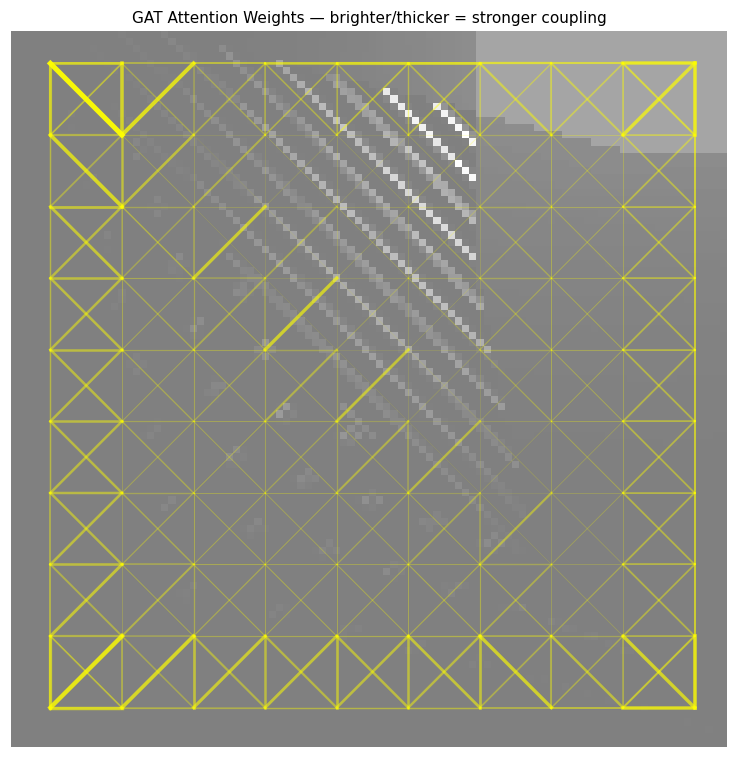

Saved → gat_attention.png


In [30]:
class GATWithAttn(nn.Module):
    """GAT that returns attention weights for the first layer."""
    def __init__(self, in_dim, hidden_dim, n_classes,
                 n_layers=N_LAYERS, dropout=DROPOUT, heads=4):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATConv(
            in_dim,
            hidden_dim // heads,
            heads=heads,
            dropout=dropout
        )
        self.bn1 = BatchNorm(hidden_dim)

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for _ in range(n_layers - 1):
            self.convs.append(GATConv(hidden_dim, hidden_dim, heads=1, dropout=dropout))
            self.bns.append(BatchNorm(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )

    def forward(self, x, edge_index, batch, return_attn=False):
        if return_attn:
            x, (edge_idx, attn_w) = self.conv1(
                x, edge_index, return_attention_weights=True
            )
        else:
            x = self.conv1(x, edge_index)
            edge_idx, attn_w = edge_index, None

        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x_pool = torch.cat(
            [global_mean_pool(x, batch), global_max_pool(x, batch)],
            dim=1
        )

        out = self.head(x_pool)

        if return_attn:
            return out, edge_idx, attn_w
        return out

# Train a small GAT with attention extraction
gat_attn = GATWithAttn(IN_DIM, HIDDEN_DIM, N_CLASSES).to(device)
opt_attn  = Adam(gat_attn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
crit_attn = nn.CrossEntropyLoss()

print("Training GAT (with attention) …")
for epoch in range(1, 51):   # quick 50-epoch run for demo
    gat_attn.train()
    for batch in train_loader:
        batch = batch.to(device)
        opt_attn.zero_grad()
        out  = gat_attn(batch.x, batch.edge_index, batch.batch)
        loss = crit_attn(out, batch.y)
        loss.backward(); opt_attn.step()

print("Done. Extracting attention weights …")

# Extract attention on a single graph
gat_attn.eval()
sample_graph = graph_list[0].to(device)
with torch.no_grad():
    _, edge_idx, attn_w = gat_attn(
        sample_graph.x, sample_graph.edge_index,
        torch.zeros(sample_graph.num_nodes, dtype=torch.long, device=device),
        return_attn=True
    )

# Mean attention across heads
attn_mean = attn_w.mean(dim=1).cpu().numpy()  # (E,)
edge_src  = edge_idx[0].cpu().numpy()
edge_dst  = edge_idx[1].cpu().numpy()

# Visualise attention on grid
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.log1p(np.abs(samples[0]['current'])),
          cmap="gray", origin="lower", alpha=0.5)

bh = bw = 100 // GRID_N
# Normalise attention for line width
attn_norm = (attn_mean - attn_mean.min()) / (attn_mean.ptp() + 1e-8)

for i, (src, dst) in enumerate(zip(edge_src, edge_dst)):
    r1, c1 = divmod(int(src), GRID_N)
    r2, c2 = divmod(int(dst), GRID_N)
    x1 = c1 * bw + bw // 2; y1 = r1 * bh + bh // 2
    x2 = c2 * bw + bw // 2; y2 = r2 * bh + bh // 2
    alpha = float(attn_norm[i]) * 0.9 + 0.05
    lw    = float(attn_norm[i]) * 3.0 + 0.3
    ax.plot([x1, x2], [y1, y2], color="yellow", alpha=alpha, lw=lw)

ax.set_title("GAT Attention Weights — brighter/thicker = stronger coupling",
             fontsize=10)
ax.axis("off")
plt.tight_layout()
#fig.savefig(OUT_DIR / "gat_attention.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved → gat_attention.png")


## 17 · Summary

In [32]:
print("\n" + "="*65)
print("  GNN Placement Prediction — Final Summary")
print("="*65)
print(f"  Graph construction: {GRID_N}×{GRID_N} grid, {CONNECTIVITY}-connected")
print(f"  Nodes per graph   : {GRID_N**2}")
print(f"  Node features     : {IN_DIM}  (current, sensor, charge, position)")
print(f"  Training epochs   : {N_EPOCHS}  |  Batch: {BATCH_SIZE}")
print()
print(f"  {'Model':<14}  {'Graph Acc':>10}")
print(f"  {'-'*28}")
for name, res in results.items():
    print(f"  {name:<14}  {res['best_acc']*100:>9.2f}%")
print()
print(f"  Node-level placement accuracy: {best_node_acc*100:.2f}%")
print()




  GNN Placement Prediction — Final Summary
  Graph construction: 10×10 grid, 8-connected
  Nodes per graph   : 100
  Node features     : 7  (current, sensor, charge, position)
  Training epochs   : 150  |  Batch: 32

  Model            Graph Acc
  ----------------------------
  GCN                 97.51%
  GAT                 93.03%
  GraphSAGE           97.01%

  Node-level placement accuracy: 97.09%

